# Single-EV proteomics — the imaging / intensity modality

The companion notebook *Single-extracellular-vesicle (single-EV)
proteomics* ran the full pipeline on **sequencing-count** data
(Proximity Barcoding Assay). But single-EV proteomics is measured on
several very different platforms:

- **sequencing counts** — PBA, DBS-Pro: integer UMI counts.
- **flow / imaging intensity** — NanoFCM nano-flow cytometry, ExoView /
  SP-IRIS, FCS files: continuous fluorescence per marker.
- **digital binary** — droplet-digital ELISA / Simoa, and per-EV imaging
  positivity calls: presence/absence per marker.

The point of this short notebook is that the **same `ov.single.ev` API**
handles all three. The only step that branches on the platform is
normalization, which reads `uns['ev']['value_type']` and does the right
thing automatically.

Here we use the **MASEV** dataset — *Multiplexed Analysis of a Single EV*
(Spitzberg, Yang *et al.*, *Nat Commun* 2023, 14:1239; PMID 36869028) —
in which individual EVs are interrogated over 5 cycles of multi-channel
immunofluorescence and each marker is read out as a **binary** per-EV
positivity call. It is an *imaging* single-EV assay, the opposite end of
the platform spectrum from PBA sequencing — yet the analysis code below is
nearly identical.


## 1. Load the MASEV data

`ov.datasets.ev_masev()` downloads the real MASEV dataset — 12,000
individual EVs x 16 markers from 4 cancer cell lines (PANC1, CAPAN-2,
ASPC1, A549). Twelve columns are single markers (CD9, CD63, CD81,
syntenin, ALIX, ...) and four are pre-computed co-localisation
combination markers. `uns['ev']['value_type']` is `'binary'`.


In [1]:
import omicverse as ov
import matplotlib.pyplot as plt

adata = ov.datasets.ev_masev()
adata

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔍 Downloading data to ./data/ev_masev.h5ad


Downloading: |                                                                                                       | 0.00/? [00:00<?, ?B/s]

Downloading:   0%|                                                                                               | 0.00/1.51M [00:00<?, ?B/s]

Downloading: 100%|█████████████████████████████████████████████████████████████████████████████████████▌| 1.51M/1.51M [00:00<00:00, 6.00MB/s]

✅ Download completed


AnnData object with n_obs × n_vars = 12000 × 16
    obs: 'sample', 'cell_type', 'condition', 'n_markers_positive'
    var: 'marker_type'
    uns: 'ev'

In [2]:
print('value type :', adata.uns['ev']['value_type'])
print('assay      :', adata.uns['ev']['assay'])
print()
print(adata.obs['sample'].value_counts())
print()
print('marker types:')
print(adata.var['marker_type'].value_counts())

value type : binary
assay      : Multiplexed Analysis of Single EV (cyclic immunofluorescence)

sample
A549       3000
ASPC1      3000
CAPAN-2    3000
PANC1      3000
Name: count, dtype: int64

marker types:
marker_type
single         12
combination     4
Name: count, dtype: int64


## 2. Quality control

The same `ov.single.ev.qc` function applies. For binary data an EV's
"total signal" is just the number of positive markers, so we require at
least one positive marker per EV.


In [3]:
adata = ov.single.ev.qc(adata, min_proteins=1, min_ev_frac=0.0)
qc = adata.uns['ev']['qc']
print(f"EVs: {qc['n_ev_in']:,} -> {qc['n_ev_out']:,} "
      f"({qc['n_ev_removed']:,} removed)")
print(f"markers: {qc['n_proteins_in']} -> {qc['n_proteins_out']}")

EVs: 12,000 -> 10,944 (1,056 removed)
markers: 16 -> 15


In [4]:
ov.single.ev.ev_summary(adata, cluster_key=None)

,n_evs,n_proteins,n_subpopulations,n_samples,value_type,platform,mean_proteins_per_ev,median_total_signal,qc_pass_rate
0,10944,15,0,4,binary,unknown,3.628015,3.0,1.0


About 1,000 EVs with no positive marker are dropped, and one marker
detected in too few EVs is removed — leaving ~11,000 EVs that carry a mean
of ~3.6 positive markers each.

## 3. Normalization — the binary path

This is the one step that differs by platform. `method='auto'` reads
`uns['ev']['value_type']`: for **count** data it applies CLR, for
**intensity** data arcsinh, and for **binary** data it is a *pass-through*
— presence/absence calls are already on the right scale. The same call
that ran CLR in the PBA notebook now correctly does nothing here.


In [5]:
ov.single.ev.normalize(adata, method='auto')
print('normalization method chosen :',
      adata.uns['ev']['normalize']['method'], '(binary -> pass-through)')
ov.single.ev.scale(adata, max_value=10)

normalization method chosen : none (binary -> pass-through)


AnnData object with n_obs × n_vars = 10944 × 15
    obs: 'sample', 'cell_type', 'condition', 'n_markers_positive', 'total_signal', 'n_proteins', 'qc_pass'
    var: 'marker_type', 'n_ev_detected', 'frac_ev_detected'
    uns: 'ev'
    layers: 'counts', 'scaled'

## 4. PCA, neighbors and EV-subpopulation clustering

PCA, the EV neighbor graph and FlowSOM clustering run exactly as in the
sequencing-count notebook.


In [6]:
ov.single.ev.pca(adata)
ov.single.ev.neighbors(adata, n_neighbors=15)
ov.single.ev.flowsom(adata, n_clusters=6, grid=(8, 8), n_epochs=20)
print(adata.obs['flowsom'].value_counts().sort_index())

flowsom
0    2090
1     927
2    1449
3    3438
4    2538
5     502
Name: count, dtype: int64


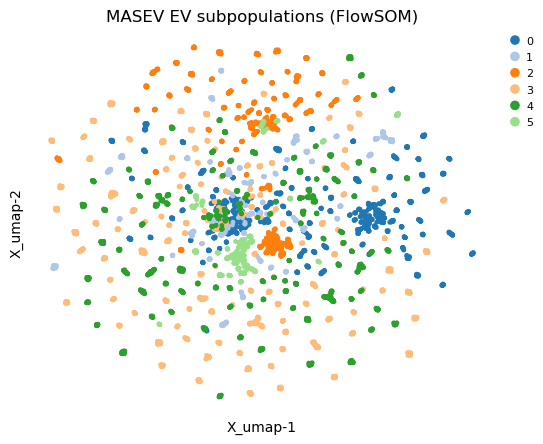

In [7]:
ov.single.ev.umap(adata)
ov.single.ev.embedding_plot(adata, color='flowsom',
                            title='MASEV EV subpopulations (FlowSOM)')
plt.show()

In [8]:
# per-subpopulation marker proteins
masev_markers = ov.single.ev.rank_markers(adata, groupby='flowsom', n_top=3)
masev_markers[['group', 'protein', 'effect_size', 'frac_in', 'padj']]

,group,protein,effect_size,frac_in,padj
0,0,SYN,0.712493,0.608134,0.000000e+00
1,0,CD98,0.704939,0.702871,0.000000e+00
2,0,CD81sc,0.688233,0.586124,0.000000e+00
3,1,CD63,2.011453,1.000000,0.000000e+00
4,1,TSG,0.029707,0.223301,2.253280e-01
5,1,MUC1,-0.076503,0.291262,2.249857e-03
6,2,CD63,2.342970,1.000000,0.000000e+00
7,2,CD63-CD9,1.373504,0.733609,0.000000e+00
8,2,CD9,0.441768,0.733609,4.821386e-96
9,3,CD9,0.530369,0.718732,8.908841e-253


## 5. Tetraspanin EV subtypes

`annotate_ev_subtype` works identically on binary data — positivity is
just the 0/1 call. MASEV measures CD9, CD63 and CD81 (column `CD81sc`)
directly.


In [9]:
ov.single.ev.annotate_ev_subtype(
    adata, tetraspanins=['CD9', 'CD81sc', 'CD63'])
print(adata.obs['ev_subtype'].value_counts())

ev_subtype
tetraspanin-negative             3355
CD9-only                         2870
double-positive (CD9/CD63)       1094
CD81sc-only                      1002
CD63-only                         961
double-positive (CD9/CD81sc)      805
triple-positive                   471
double-positive (CD81sc/CD63)     386
Name: count, dtype: int64


As in the PBA data, a large tetraspanin-negative fraction sits alongside
single- and double-positive subsets and a small triple-positive core —
the same MISEV2023 picture reproduced on an independent platform.

## 6. Marker colocalization

The single-vesicle advantage carries over directly. We compute
colocalization on the **single** markers (the four pre-computed
combination markers are excluded to avoid circularity — they already
encode co-localization).


In [10]:
coloc = ov.single.ev.colocalization(
    adata, markers=['CD9', 'CD63', 'CD81sc', 'CD47', 'TSG', 'EGFR', 'MUC1'])
coloc[['markers', 'n_copos', 'jaccard', 'obs_exp', 'padj']].head(8)

,markers,n_copos,jaccard,obs_exp,padj
0,CD9+MUC1,1787,0.250140,1.011173,2.692984e-01
1,CD9+CD47,1725,0.252562,1.086802,1.046472e-08
2,CD9+CD63,1565,0.237589,1.122452,3.046555e-13
3,CD9+CD81sc,1276,0.192517,1.000371,5.342805e-01
4,CD47+MUC1,1118,0.189878,0.999978,5.342805e-01
5,CD63+MUC1,1067,0.192738,1.086438,8.394414e-05
6,CD9+TSG,1029,0.158747,0.946331,9.972738e-01
7,CD9+EGFR,1002,0.159987,1.033445,7.593795e-02


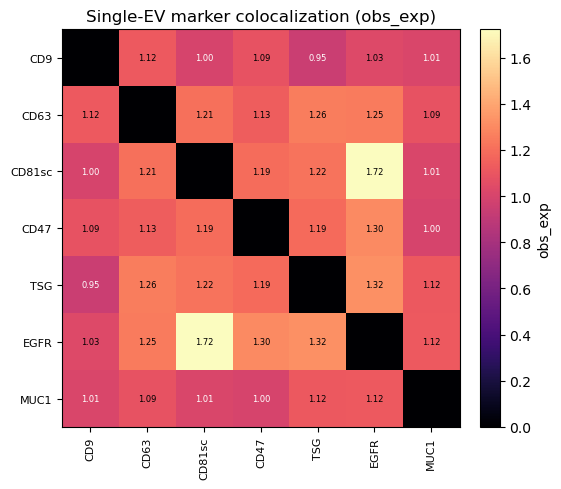

In [11]:
ov.single.ev.colocalization_plot(coloc, value='obs_exp', cmap='magma')
plt.show()

CD9 co-occurs with CD63 and with CD47 on the same vesicles above chance
(observed/expected > 1, p < 1e-8) — independent imaging-based
confirmation of tetraspanin co-localization, the same kind of finding the
PBA notebook reached from sequencing counts.

## 7. Differential subpopulation analysis across cell lines

Each cancer cell line sheds a different EV-subpopulation mixture.
`differential_subpopulation` tests the frequency shift between two cell
lines.


In [12]:
ds = ov.single.ev.differential_subpopulation(
    adata, condition_key='sample', cluster_key='flowsom',
    group_a='PANC1', group_b='A549')
ds

,cluster,frac_a,frac_b,delta_frac,log2_ratio,stat,test,pval,padj
0,2,0.132765,0.193269,-0.060503,-0.541728,-6.176966,two_proportion_z,6.534523e-10,3.920714e-09
1,3,0.369187,0.324427,0.044760,0.186456,3.550075,two_proportion_z,3.851214e-04,1.155364e-03
2,4,0.152645,0.182165,-0.029521,-0.255070,-2.983249,two_proportion_z,2.852058e-03,5.704117e-03
3,5,0.063188,0.045802,0.017386,0.464250,2.893417,two_proportion_z,3.810751e-03,5.716127e-03
4,0,0.203408,0.182512,0.020896,0.156383,1.999032,two_proportion_z,4.560494e-02,5.472592e-02
5,1,0.078807,0.071825,0.006982,0.133840,0.998834,two_proportion_z,3.178753e-01,3.178753e-01


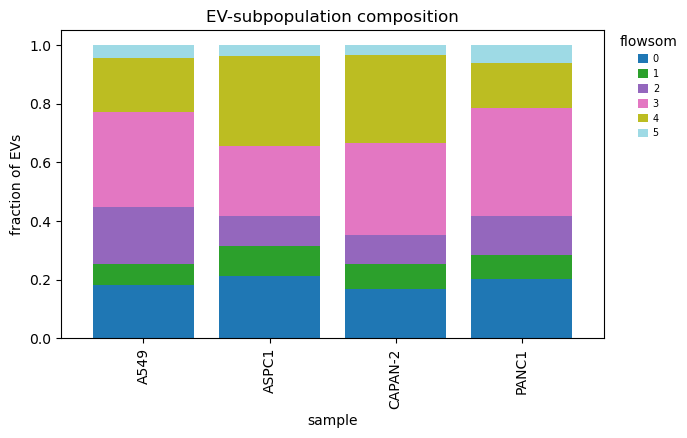

In [13]:
ov.single.ev.subpopulation_composition_plot(
    adata, groupby='sample', cluster_key='flowsom')
plt.show()

## Synthesis — one API, two platforms

This short notebook re-ran the `ov.single.ev` pipeline on the **MASEV**
cyclic-immunofluorescence dataset — an *imaging* single-EV assay with
**binary** per-EV marker calls, as different from PBA sequencing as two
single-EV platforms can be:

- ~11,000 individual EVs x 15 markers after QC, 4 cancer cell lines.
- **6** FlowSOM EV subpopulations, each with a distinct marker signature.
- Tetraspanin subtyping reproduced the MISEV2023 picture — a large
  tetraspanin-negative fraction plus single/double/triple-positive
  subsets.
- Colocalization confirmed CD9-CD63 / CD9-CD47 co-occurrence on the same
  vesicles, an imaging-based echo of the PBA colocalization result.
- Differential subpopulation analysis showed each cell line sheds a
  distinct EV-subpopulation mixture.

The code differs from the sequencing-count notebook in essentially one
place: `normalize` chose a binary pass-through instead of CLR, driven
entirely by `uns['ev']['value_type']`. Everything else — QC, PCA,
FlowSOM, subtyping, colocalization, differential testing — is the same
API. That is the design goal of `ov.single.ev`: **one single-EV
proteomics workflow, platform-agnostic across sequencing, flow/imaging
intensity and digital binary data.**
